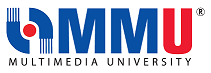

<center> <h1 style="font-size:2vw"> TDW 6323 Data Wrangling and Visualisation </h1></center>

<center> <h1 style="font-size:2vw"> Lab 12 Temporal Visualisation </h1></center>
<hr style="height:2px">

This lab introduces different types of temporal visualization (create interactive visualizations to present **data over
a period of time**). Plotting data against time provides insights into **trends, seasonality, outliers and important events** from a dataset. Adding a time dimension on a static plot with interactivity on top of that provides the freedom to explore and analyze the data.

In temporal data visualization, **time is the independent variable** and the other features that are being visualized are plotted against time. So, the other features are dependent variables. Usually, **time is plotted on the $x$-axis**, while the dependent variables are plotted on the $y$-axis.

**Time-series data** is a more refined version of temporal data where observations are taken at equally spaced points in time successively. With **temporal data**, on the other hand, observations are simply attached to time, and the intervals may not be equally spaced. Temporal data can be represented with interactive visualisations across **geographical data**.

# Exercise 1: Aggregate time periods

<dd> 1. Import the necessary modules, demonstrate <b>upsampling</b>: </dd>

In [1]:
from datetime import datetime
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Read the dataset using pandas and drop the NA values:
walmart_stores = pd.read_csv('1962_2006_walmart_store_openings.csv', 
                             parse_dates=['date_super']).dropna()




In [2]:
# Count the number of stores opened per year.
walmart_store_count = walmart_stores.groupby("YEAR")[["storenum"]].agg("count").rename(columns={"storenum": "store_count"})



In [3]:
#Merge walmart_store_count with walmart_stores
walmart_store_count = pd.merge(walmart_stores, walmart_store_count, on="YEAR")
walmart_store_count= walmart_store_count.set_index(pd.DatetimeIndex(walmart_store_count.date_super))



In [4]:
# Filter out the required columns
walmart_store_count = walmart_store_count[["date_super", "store_count"]]
walmart_store_count.drop_duplicates(subset="date_super", inplace=True)
# walmart_store_count.head(8)



In [6]:
# Convert walmart_store_count_series to 2-days frequency (UPSAMPLING helps to visualize and analyse data in more detail)
walmart_store_count_series = walmart_store_count.store_count
walmart_store_count_series = walmart_store_count_series.asfreq('2D')
# walmart_store_count_series.head()



<AxesSubplot:xlabel='date_super'>

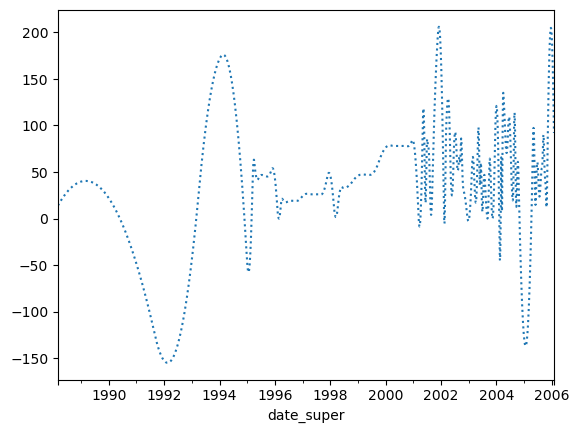

In [7]:
# Interpolate the missing values using linear method
walmart_store_count_series = walmart_store_count_series.interpolate(method="spline", order=2)
walmart_store_count_series.plot(style=":") 

<dd> 2. Smoothen out the plot using <b>downsampling</b> to higher granularity of time (e.g. day to week), will
introduce smoothing: </dd>

<dd> 3. <b>Downsample</b> with frequency from Business-Quarter: </dd>

<dd> 4. Using <b>shift</b> and <b>tshift</b> to Introduce a Lag in Time-Series Data.</dd> <br>
• <b>tshift:</b> Shifts the datetime index of the DataFrame by a given period. The period is unit count of frequency; frequency could be week, month, hour, and so on. It changes the value of DateTimeIndex within the DataFrame.

• <b>shift:</b> Shifts the DataFrame index by a given period. In the process, new rows or columns will be introduced in the DataFrame with NaN values.

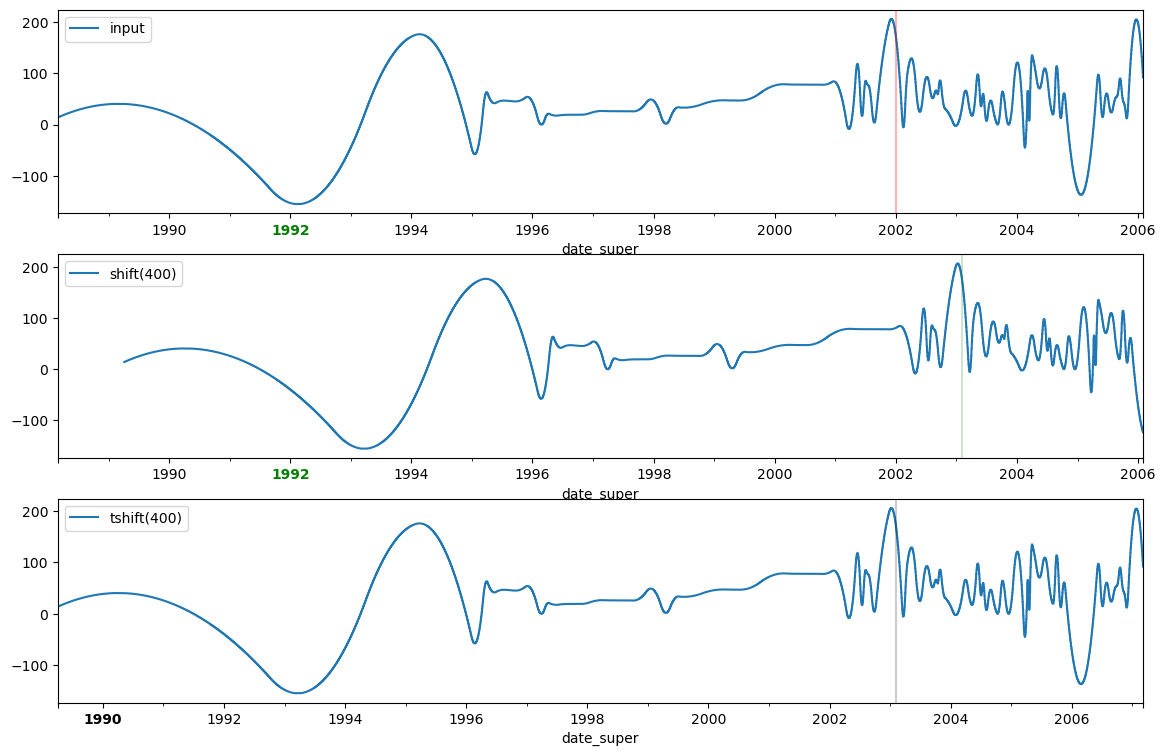

In [9]:
# get data at frequency of 1 day
walmart_store_count_series = walmart_store_count_series.asfreq('D', method='pad')

fig, ax = plt.subplots(3, figsize=(14,9))
shift_val = 400

#create 3 plots, one normal, one shifted with index, and other shifted with time
walmart_store_count_series.plot(ax=ax[0])
#shift the date by shift_val
walmart_store_count_series.shift(shift_val).plot(ax=ax[1])
#shift the time index using tshift
walmart_store_count_series.shift(shift_val,freq='D').plot(ax=ax[2])

#slect a date to draw line on plot
date_max = pd.to_datetime('2002-01-01')
delta = pd.Timedelta(shift_val, 'D')

#Put marker on three plot to undestand how thsift shifting the index and shift is changing the data.
ax[0].legend(['input'], loc=2)
ax[0].get_xticklabels()[2].set(weight='heavy', color='green')
ax[0].axvline(date_max, alpha=0.3, color='red')

ax[1].legend(['shift({})'.format(shift_val)], loc=2)
ax[1].get_xticklabels()[2].set(weight='heavy', color='green')
ax[1].axvline(date_max + delta, alpha=0.2, color='green')

ax[2].legend(['tshift({})'.format(shift_val)], loc=2)
ax[2].get_xticklabels()[1].set(weight='heavy', color='black')
ax[2].axvline(date_max + delta, alpha=0.2, color='black');


<dd> 5. Adding Interactivity to Static Line Plots Using <b>Bokeh</b>: </dd>

In [10]:
# import required libraries
import pandas as pd
from bokeh.plotting import figure, output_notebook, show, ColumnDataSource
from bokeh.io import push_notebook, show, output_notebook
from ipywidgets import interact
output_notebook()

# initalize the figure
TOOLTIPS = [
    ("date", "@date"),
    ("value", "@close")
]
p = figure(title="Interactive plot to change line width and color", plot_width=900,
           plot_height=400, x_axis_type="datetime", tooltips=TOOLTIPS)



Loading BokehJS ...

In [11]:
# helper function to return dataframes.
def prepare_data():
    microsoft_stock = pd.read_csv( "microsoft_stock_ex6.csv")
    microsoft_stock["date"] = pd.to_datetime(microsoft_stock["date"])
    google_stock = pd.read_csv( "google_stock_ex6.csv")
    google_stock["date"] = pd.to_datetime(google_stock["date"])
    
    return microsoft_stock, google_stock



In [12]:
# call the helper function to get the dataframes
microsoft_stock, google_stock = prepare_data()

# Add the lines for both dataframes
microsoft_line=p.line("date","close", source=microsoft_stock, line_width=1.5, legend_label="microsoft_stock")
google_line = p.line("date", "close", source=google_stock, line_width=1.5, legend_label="google_stock")



In [13]:
#custom function define how to interact for user event.
def update(color, width=1):
    google_line.glyph.line_color = color
    google_line.glyph.line_width = width
    push_notebook()

# plot the required libraries
interact(update, color=["red", "green", "gray"], width=(1,5))
show(p, notebook_handle=True)

interactive(children=(Dropdown(description='color', options=('red', 'green', 'gray'), value='red'), IntSlider(…

# Exercise 2: Creating a Worldwide Choropleth Map

<dd> 1. Import the necessary modules to generate an interactive worldwide map. </dd>

In [ ]:
#Import the python modules:
import pandas as pd

#Read the data from the .csv file:
internet_usage_url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/share-of-individuals-using-the-internet.csv"
internet_usage_df = pd.read_csv(internet_usage_url)
#internet_usage_df.head()

#Subset the data to one specific year since the DataFrame contains records from multiple years:
internet_usage_2016 = internet_usage_df.query("Year==2016")
internet_usage_2016.head()


In [ ]:
!pip install plotly

In [ ]:
#Add title text to the choropleth map
import plotly.express as px
import pandas as pd

fig = px.choropleth(internet_usage_2016,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", # column by which to color-code
                    hover_name="Country", # column to display in hover information                    color_continuous_scale=px.colors.sequential.Plasma)
                   )
fig.update_layout(
    # add a title text for the plot
    title_text = 'Internet usage across the world (% population) - 2016'
)

fig.show()

<dd> 2. Zooming into a specific region: </dd>

In [ ]:
#Set geo_scope to asia in the update_layout function:
import plotly.express as px
fig = px.choropleth(internet_usage_2016,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", # column by which to color-code
                    hover_name="Country", # column to display in hover information
                    color_continuous_scale=px.colors.sequential.Plasma)

fig.update_layout(
    # add a title text for the plot
    title_text = 'Internet usage across the Asian Continent (% population) - 2016',
    geo_scope = 'asia' # can be set to north america | south america | africa | asia | europe | usa
)

fig.show()

<dd> 3. Changing the map projection from flat to natural earth: </dd>

In [ ]:
#Set the projection type to natural earth:
import plotly.express as px
fig = px.choropleth(internet_usage_2016,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", # column by which to color-code
                    hover_name="Country", # column to display in hover information
                    color_continuous_scale=px.colors.sequential.Plasma)

fig.update_layout(
    # add a title text for the plot
    title_text = 'Internet usage across the world (% population) - 2016',
    # set projection style for the plot
    geo = dict(projection={'type':'natural earth'}) # by default, projection type is set to 'equirectangular'
)

fig.show()

<dd> 4. Adding Animation to a Choropleth Map: </dd>

In [ ]:
#Add animation to year column using animation_frame=year:
import plotly.express as px
fig = px.choropleth(internet_usage_df, locations="Code",
                    color="Individuals using the Internet (% of population)", # lifeExp is a column of gapminder
                    hover_name="Country", # column to add to hover information
                    animation_frame="Year", # column on which to animate
                    color_continuous_scale=px.colors.sequential.Plasma)
                    
fig.update_layout(
    # add a title text for the plot
    title_text = 'Internet usage across the world (% population)',
    # set projection style for the plot
    geo = dict(projection={'type':'natural earth'}) # by default, projection type is set to 'equirectangular'
)

fig.show()


<dd> 5. Creating a Bubble Plot on a Geographical Map: </dd>

In [ ]:
internet_users_url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/number-of-internet-users-by-country.csv"
internet_users_df = pd.read_csv(internet_users_url)
internet_users_df.sort_values(by=['Year'],inplace=True)

#Now, Let’s animate the bubble plot to show increase in number of internet users across the years, by using the animation_frame parameter.
import plotly.express as px

fig = px.scatter_geo(internet_users_df, 
                    locations="Code", # name of column indicating country-codes
                    size="Number of internet users (users)", # name of column by which to size the bubble
                    hover_name="Country", # name of column to be displayed while hovering over the map
                    size_max=80, # parameter to scale all bubble size
                    animation_frame="Year",
                    )
                    
fig.update_layout(
    # add a title text for the plot
    title_text = 'Internet users across the world',
    # set projection style for the plot
    geo = dict(projection={'type':'natural earth'}) # by default, projection type is set to 'equirectangular'
)

fig.show()

# Exercise 3: Determine Which Features to Visualize

<dd> 1. Import the necessary modules: </dd>

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

url_co2 = 'https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/co2.csv'
url_gm = 'https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/gapminder.csv'
co2 = pd.read_csv(url_co2)
gm = pd.read_csv(url_gm)

df_gm = gm[['Country', 'region']].drop_duplicates()


In [ ]:
df_w_regions = pd.merge(co2, df_gm, left_on='country', right_on='Country', how='inner')
df_w_regions = df_w_regions.drop('Country', axis='columns')


In [ ]:
new_co2 = pd.melt(df_w_regions, id_vars=['country', 'region'])
columns = ['country', 'region', 'year', 'co2']
new_co2.columns = columns
df_co2 = new_co2[new_co2['year'].astype('int64') > 1963]
df_co2 = df_co2.sort_values(by=['country', 'year'])
df_co2['year'] = df_co2['year'].astype('int64')



In [ ]:
df_g = gm[['Country', 'Year', 'gdp', 'population', 'fertility', 'life']]
df_g.columns = ['country', 'year', 'gdp', 'population', 'fertility', 'life']
data = pd.merge(df_co2, df_g, on=['country', 'year'], how='left')
data = data.dropna()
data.head()

<dd> 2. Visualize the relationship and check the correlation between <b>co2</b> and <b>life</b> using a scatter graph: </dd>

In [ ]:
fig = px.scatter(data, x="life", y="co2", size="population", color="region", animation_frame = 'year', 
                  animation_group = 'country', hover_name="country", size_max=60)
fig.show()

np1 = np.array(data['co2'])
np2 = np.array(data['life'])
np.corrcoef(np1, np2)

<dd> 3. Visualize the relationship and check the correlation between <b>co2</b> and <b>fertility</b> using a scatter graph: </dd>

In [ ]:
fig = px.scatter(data, x="fertility", y="co2", size="population", color="region", 
                 animation_frame = 'year', animation_group = 'country', hover_name="country",
                 size_max=60)
fig.show()

np1 = np.array(data['co2'])
np2 = np.array(data['fertility'])
np.corrcoef(np1, np2)
